In [1]:
# Phase 5 — Spatial & Geographic Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

df = pd.read_csv('cleaned_weather_data.csv')

# Average temperature per country
country_temp = df.groupby(['country', 'latitude', 'longitude'])\
                 ['temperature_celsius'].mean().reset_index()

# Create interactive world heatmap
m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron')

heat_data = [[row['latitude'], row['longitude'], 
              row['temperature_celsius']] for _, row in country_temp.iterrows()]

HeatMap(heat_data, radius=15, blur=10, min_opacity=0.5).add_to(m)
m.save('map_temperature_heatmap.html')
print("✅ Interactive map saved as 'map_temperature_heatmap.html'")
print(f"Countries mapped: {len(country_temp)}")

✅ Interactive map saved as 'map_temperature_heatmap.html'
Countries mapped: 445


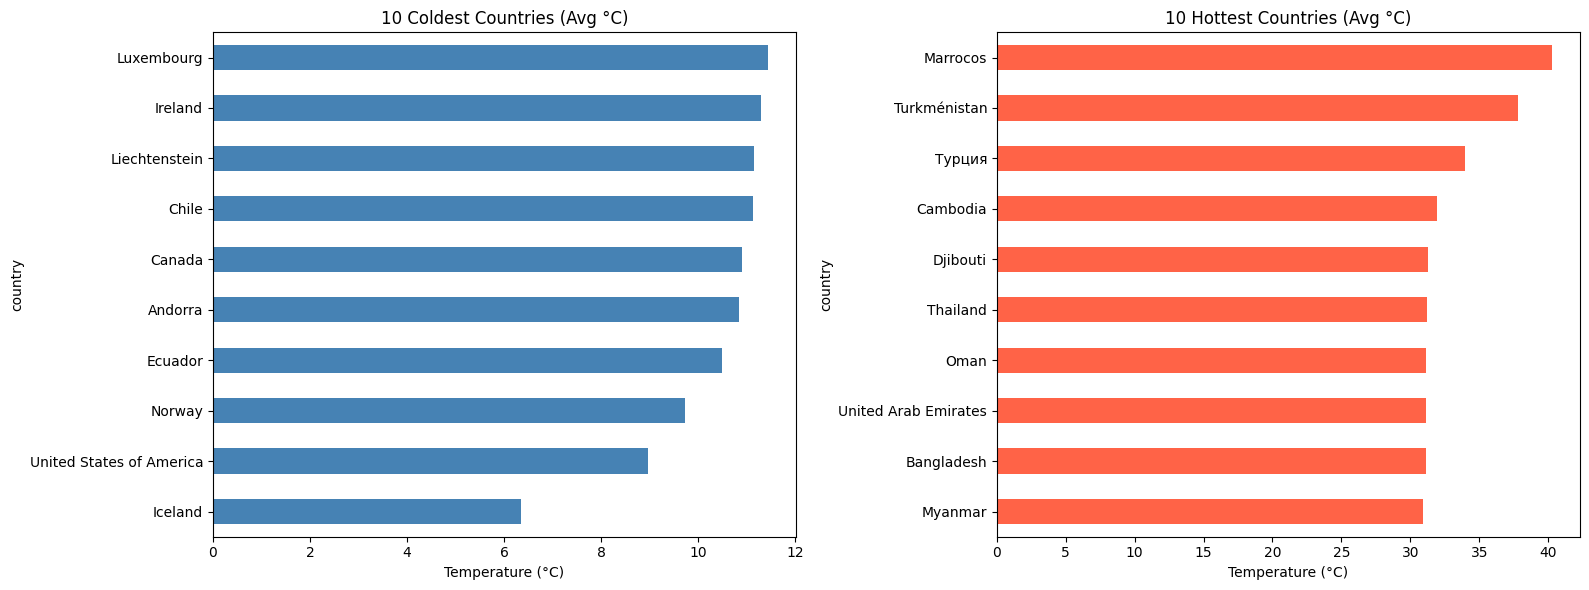


=== Air Quality vs Temperature Correlation ===
                             temperature_celsius  air_quality_PM2.5  \
temperature_celsius                        1.000              0.056   
air_quality_PM2.5                          0.056              1.000   
air_quality_PM10                           0.102              0.649   
air_quality_Carbon_Monoxide                0.011              0.613   

                             air_quality_PM10  air_quality_Carbon_Monoxide  
temperature_celsius                     0.102                        0.011  
air_quality_PM2.5                       0.649                        0.613  
air_quality_PM10                        1.000                        0.163  
air_quality_Carbon_Monoxide             0.163                        1.000  


In [2]:
# Top 20 hottest and coldest countries
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

country_avg = df.groupby('country')['temperature_celsius'].mean().sort_values()

# Coldest 10
country_avg.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('10 Coldest Countries (Avg °C)')
axes[0].set_xlabel('Temperature (°C)')

# Hottest 10
country_avg.tail(10).plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('10 Hottest Countries (Avg °C)')
axes[1].set_xlabel('Temperature (°C)')

plt.tight_layout()
plt.savefig('plot_country_temps.png', dpi=150)
plt.show()

# Air quality vs temperature correlation
print("\n=== Air Quality vs Temperature Correlation ===")
print(df[['temperature_celsius', 'air_quality_PM2.5', 
          'air_quality_PM10', 'air_quality_Carbon_Monoxide']].corr().round(3))